---
title: Downloading Climate Data from Optimized ERA5-Land Zarr Archives
short_title: ERA5-Land (Optimized)
---

In this notebook we will demonstrate how we can use Climate Tools and `dhis2eo` to efficiently retrieve climate data from optimized Zarr archives of the [ERA5-Land dataset](https://earthdatahub.destine.eu/collections/era5/datasets/reanalysis-era5-land), hosted at the [DestinE Earth Data Hub](https://earthdatahub.destine.eu/catalogue). 

It should be noted that this is an alternative to the examples showing how to [get ERA5-Land data from the Climate Data Store](../climate-data-store/era5-download.ipynb). The benefit of getting ERA5-Land data from DestinE is that it fetches the data from cloud-optimized Zarr archives, which is much faster than getting the same data from the Climate Data Store. 

**Important:** Make sure you have followed [these instructions](api-authentication.md) to authenticate and allow access the Earth Data Hub zarr files. 

--------------------------------------------
## What you need

We start by importing the necessary libraries:

In [1]:
import geopandas as gpd
import xarray as xr

from dhis2eo.data.destine import era5_land

In order to know which geographical area we should download data for, we also load our Sierra Leone organisation unit GeoJSON file downloaded from DHIS2. Alternative, see our [guide for how to fetch organisation units directly from your DHIS2 instance](../../org-units/download-web-api.ipynb). 

In [2]:
org_units = gpd.read_file('../../data/sierra-leone-districts.geojson')
org_units

,type,id,name,hasCoordinatesDown,hasCoordinatesUp,level,grandParentParentGraph,grandParentId,parentGraph,parentId,parentName,dimensions,weight,geometry
0,Polygon,O6uvpzGd5pu,Bo,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"POLYGON ((-11.5914 8.4875, -11.5906 8.4769, -1..."
1,Polygon,fdc6uOvgoji,Bombali,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"POLYGON ((-11.8091 9.2032, -11.8102 9.1944, -1..."
2,MultiPolygon,lc3eMKXaEfw,Bonthe,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"MULTIPOLYGON (((-12.5568 7.3832, -12.5574 7.38..."
3,Polygon,jUb8gELQApl,Kailahun,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"POLYGON ((-10.7972 7.5866, -10.8002 7.5878, -1..."
4,MultiPolygon,PMa2VCrupOd,Kambia,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"MULTIPOLYGON (((-13.1349 8.8471, -13.1343 8.84..."
5,Polygon,kJq2mPyFEHo,Kenema,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"POLYGON ((-11.3596 8.5317, -11.3513 8.5234, -1..."
6,Polygon,qhqAxPSTUXp,Koinadugu,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"POLYGON ((-10.585 9.0434, -10.5877 9.0432, -10..."
7,Polygon,Vth0fbpFcsO,Kono,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"POLYGON ((-10.585 9.0434, -10.5848 9.0432, -10..."
8,MultiPolygon,jmIPBj66vD6,Moyamba,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"MULTIPOLYGON (((-12.6351 7.6613, -12.6346 7.66..."
9,MultiPolygon,TEQlaapDQoK,Port Loko,True,False,2,,,ImspTQPwCqd,ImspTQPwCqd,Sierra Leone,{},1,"MULTIPOLYGON (((-13.119 8.4718, -13.1174 8.470..."


--------

## Downloading ERA5-Land data

The `dhis2eo.data.destine.era5_land` module allows you to easily access and download climate data from DestinE's optimized zarr-archive of the ERA5-Land dataset. 

### Hourly data

To import daily ERA5-Land data into DHIS2, we recommend using `era5_land.hourly` to download the hourly version of the data, and then [aggregating up to the daily level](../../aggregation/time-period-aggregation.ipynb). This allows you to define the correct days for your local timezone when [aggregating from hourly to daily values](../../aggregation/time-period-aggregation.ipynb). 

#### Parameters

We set the `start` and `end` parameters to only get climate data for the months of July, August, and September of 2025, and set the bounding box (`bbox`) to only get data for the spatial extent of the org units. 

We also specify a `dirname` for where the data should be saved and a `prefix` for naming the downloaded files.

Finally, we specify which climate `variables` we want to download - specifically 2m temperature and total precipitation. For a list of all the available ERA5-Land variables, see the Earth Data Hub's [ERA5-Land Dataset Page](https://earthdatahub.destine.eu/collections/era5/datasets/reanalysis-era5-land). 

In [3]:
start = "2025-07"
end = "2025-09"
bbox = org_units.total_bounds
dirname = '../../data/local'
prefix = 'era5land_hourly_sierra_leone'
variables = ["t2m", "tp"]

#### Download to disk

Run the download function which will retrieve the data one month at a time to the location you specified. Downloads can take a few minutes for each month downloaded. The returned list shows the location of the downloaded files: 

In [4]:
files = era5_land.hourly.download(start=start, end=end, bbox=bbox, dirname=dirname, prefix=prefix, variables=variables)
files

INFO - 2026-04-27 11:59:12,890 - dhis2eo.data.destine.era5_land.hourly - Month 2025-7
INFO - 2026-04-27 11:59:12,893 - dhis2eo.data.destine.era5_land.hourly - Opening zarr archive from https://data.earthdatahub.destine.eu/era5/reanalysis-era5-land-no-antartica-v0.zarr
INFO - 2026-04-27 11:59:22,693 - dhis2eo.data.destine.era5_land.hourly - Correcting longitude coords to range -180 to 180
INFO - 2026-04-27 11:59:30,292 - dhis2eo.data.destine.era5_land.hourly - Computing bbox to use for subsetting
INFO - 2026-04-27 11:59:30,298 - dhis2eo.data.destine.era5_land.hourly - Subsetting zarr archive to bbox with padding: -13.403500000000022 6.817599999999999 -10.165799999999978 10.100400000000002
INFO - 2026-04-27 11:59:30,302 - dhis2eo.data.destine.era5_land.hourly - Subsetting zarr archive to date range: 2025-07-01 to 2025-07-31
INFO - 2026-04-27 11:59:30,325 - dhis2eo.data.destine.era5_land.hourly - Saving data from DestinE Earth Data Hub...
INFO - 2026-04-27 11:59:30,325 - dhis2eo.data.dest

[WindowsPath('C:/Users/karimba/Documents/Github/climate-tools/docs/guides/data/local/era5land_hourly_sierra_leone_2025-07.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/climate-tools/docs/guides/data/local/era5land_hourly_sierra_leone_2025-08.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/climate-tools/docs/guides/data/local/era5land_hourly_sierra_leone_2025-09.nc')]

The download function treats the files saved under the given `dirname` and `prefix` as a cache, so it can safely be rerun multiple times without re-downloading. To ignore the cache and fetch fresh data you can set `overwrite=True`.

#### Inspect the data

Now that the files exists on disk, there are many ways we could work with them. For now, let's open the files as a single xarray dataset, by passing them to `xr.open_mfdataset()`:

In [5]:
ds = xr.open_mfdataset(files)

Inspecting the data we see that the xarray dataset contains the data variables `t2m` (2m temperature), and `tp` (total precipitation), and has 2208 hours in the time dimension (or 3 months of hourly data):

In [6]:
ds

<xarray.Dataset> Size: 19MB
Dimensions:              (valid_time: 2208, latitude: 33, longitude: 33)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 18kB 2025-07-01 ... 2025...
  * latitude             (latitude) float64 264B 10.1 10.0 9.9 ... 7.1 7.0 6.9
  * longitude            (longitude) float64 264B -13.4 -13.3 ... -10.3 -10.2
    depthBelowLandLayer  float64 8B 100.0
    number               int64 8B 0
    surface              float64 8B 0.0
Data variables:
    t2m                  (valid_time, latitude, longitude) float32 10MB dask.array<chunksize=(744, 33, 33), meta=np.ndarray>
    tp                   (valid_time, latitude, longitude) float32 10MB dask.array<chunksize=(744, 33, 33), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-10-29T11:44 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Finally, let's check what the precipitation (`tp`) was at 12:00 on August 31:

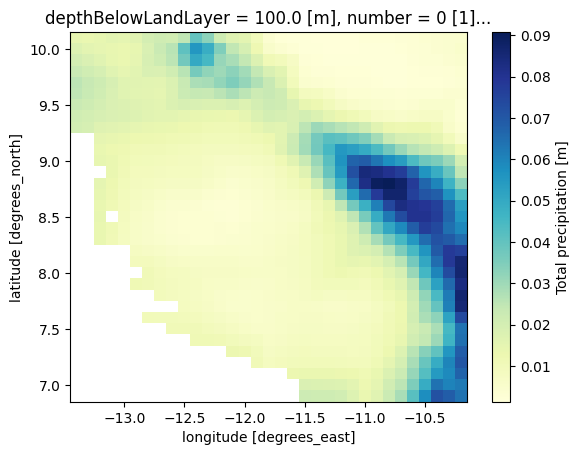

In [8]:
ds.sel(valid_time='2025-08-31T12:00')['tp'].plot(cmap='YlGnBu')

**Important**: Since DHIS2 does not deal directly with hourly data, you will also need to [aggregate from hourly to daily data](../../aggregation/time-period-aggregation.ipynb) before you can import the data to DHIS2. 

## Next steps

This notebook has showed how to download both hourly and monthly ERA5-Land climate data. For guidance on what to do with the data after downloading, see: 

* [Aggregate the data](../../aggregation/intro.md).
* [Import the aggregated data to DHIS2](../../import-data/intro.md).

If you want to skip to the end, you can also check out [this example workflow](/workflows/import-era5/import-era5-daily) that includes all the steps needed to download and import ERA5-Land data from start to finish. 